In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/34K E-commerce Sales Transcations Dataset.csv')

# Display first 5 rows
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,23-12-2023,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,03-04-2025,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,08-10-2024,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,14-09-2024,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,21-12-2024,6,East,No,13.88,2.74,1.15,39,Male


In [2]:
# Check dataset dimensions
print("Dataset Shape:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types and missing values
print("\nDataset Information:")
df.info()

Dataset Shape: (34500, 17)

Column Names:
['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivery_time_days', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null 

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Check unique values in categorical columns
print("\nCategories:", df['category'].unique())
print("Payment Methods:", df['payment_method'].unique())
print("Regions:", df['region'].unique())
print("Returned Status:", df['returned'].unique())
print("Customer Gender:", df['customer_gender'].unique())

Missing Values:
order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

Duplicate Rows: 0

Categories: ['Home' 'Grocery' 'Electronics' 'Beauty' 'Fashion' 'Toys' 'Sports']
Payment Methods: ['Credit Card' 'UPI' 'COD' 'PayPal' 'Debit Card' 'Wallet']
Regions: ['West' 'South' 'North' 'East' 'Central']
Returned Status: ['No' 'Yes']
Customer Gender: ['Female' 'Male' 'Other']


In [4]:
# Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Verify data type
print("Order Date Data Type:", df['order_date'].dtype)

# Numerical columns summary
numerical_columns = [
    'price',
    'discount',
    'quantity',
    'delivery_time_days',
    'total_amount',
    'shipping_cost',
    'profit_margin',
    'customer_age'
]

print("\nNumerical Data Summary:")
display(df[numerical_columns].describe())

Order Date Data Type: datetime64[ns]

Numerical Data Summary:


,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


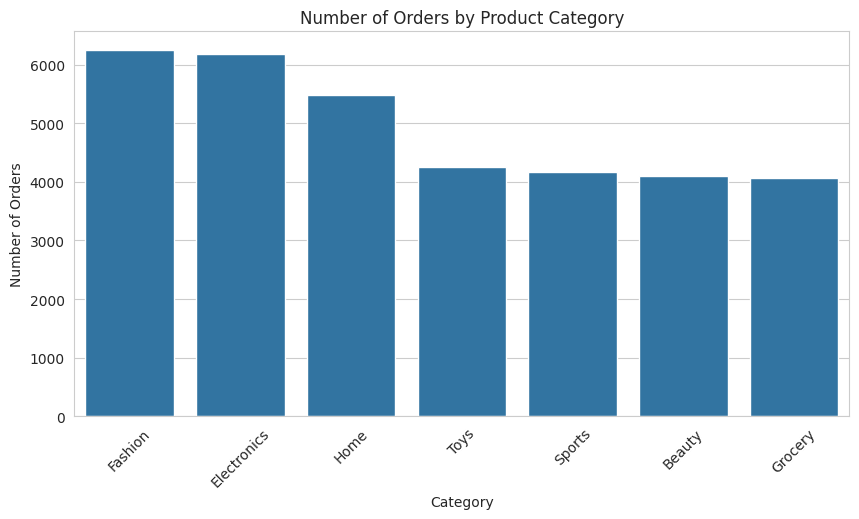

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style("whitegrid")

# Category distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index)
plt.title('Number of Orders by Product Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

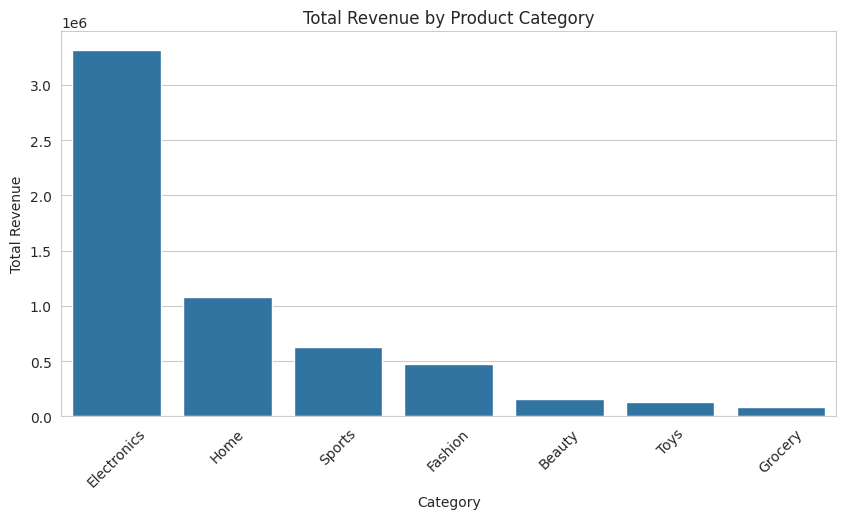

In [6]:
# Revenue by Product Category
category_revenue = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title('Total Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

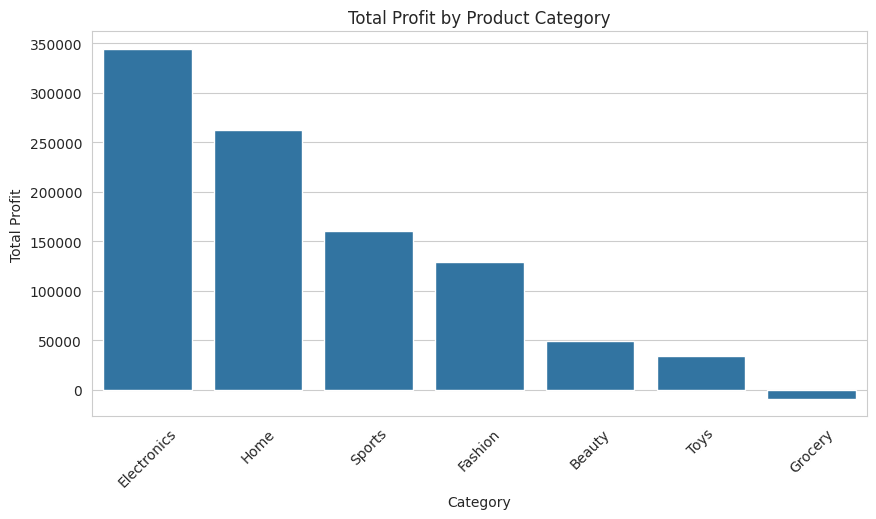

In [7]:
# Total Profit by Product Category
category_profit = df.groupby('category')['profit_margin'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title('Total Profit by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

In [8]:
# Check profit margin as a percentage of total amount

df['profit_percentage'] = (df['profit_margin'] / df['total_amount']) * 100

print("Profit Percentage Summary:")
display(df['profit_percentage'].describe())

print("\nSample Data:")
display(df[['total_amount', 'profit_margin', 'profit_percentage']].head(10))

Profit Percentage Summary:


,profit_percentage
count,34500.000000
mean,10.905159
std,22.695934
min,-380.232558
25%,6.662194
50%,16.159647
75%,24.927819
max,45.086705



Sample Data:


,total_amount,profit_margin,profit_percentage
0,139.47,31.17,22.348892
1,24.73,-2.62,-10.594420
2,166.80,13.44,8.057554
3,63.67,2.14,3.361081
4,13.88,1.15,8.285303
5,97.04,37.35,38.489283
6,266.50,22.88,8.585366
7,9.98,-0.02,-0.200401
8,6.28,-1.23,-19.585987
9,10.91,-1.89,-17.323556


In [9]:
print("Earliest Order Date:", df['order_date'].min())
print("Latest Order Date:", df['order_date'].max())

Earliest Order Date: 2023-09-12 00:00:00
Latest Order Date: 2025-09-11 00:00:00


In [10]:
# Monthly Sales Trend

monthly_sales = df.groupby(
    df['order_date'].dt.to_period('M')
)['total_amount'].sum()

print(monthly_sales.head())

order_date
2023-09    151135.60
2023-10    262502.74
2023-11    240286.91
2023-12    255617.03
2024-01    217766.09
Freq: M, Name: total_amount, dtype: float64


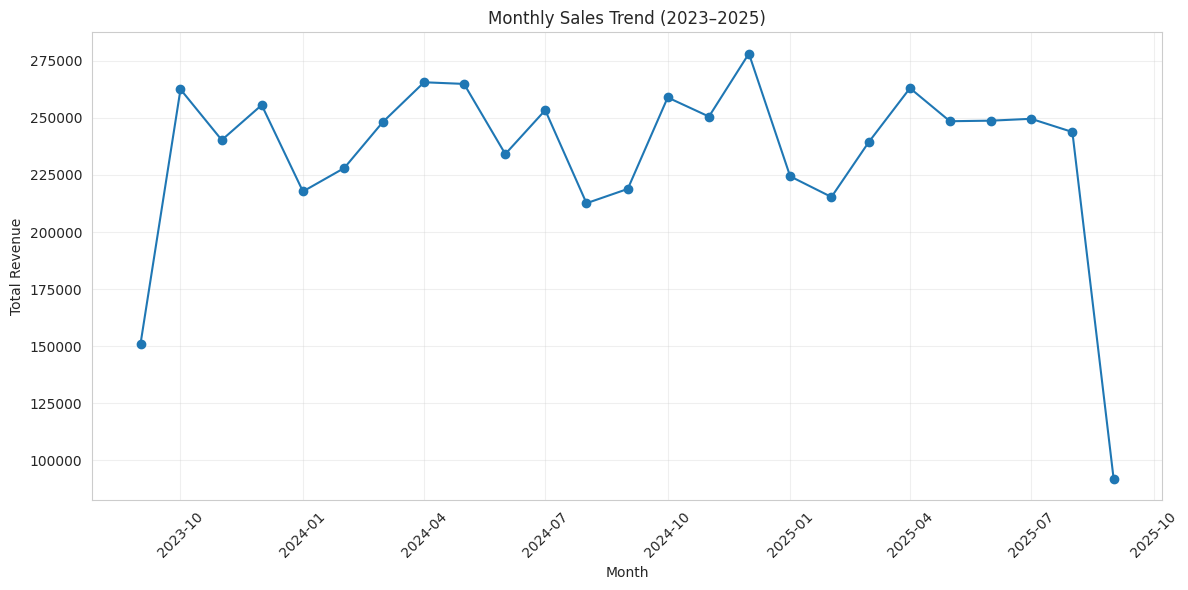

In [11]:
import matplotlib.pyplot as plt

# Convert period index to timestamp
monthly_sales.index = monthly_sales.index.to_timestamp()

# Create line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend (2023–2025)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Number of orders per month
monthly_orders = df.groupby(
    df['order_date'].dt.to_period('M')
)['order_id'].count()

print(monthly_orders.tail(6))

order_date
2025-04    1431
2025-05    1494
2025-06    1430
2025-07    1471
2025-08    1498
2025-09     555
Freq: M, Name: order_id, dtype: int64


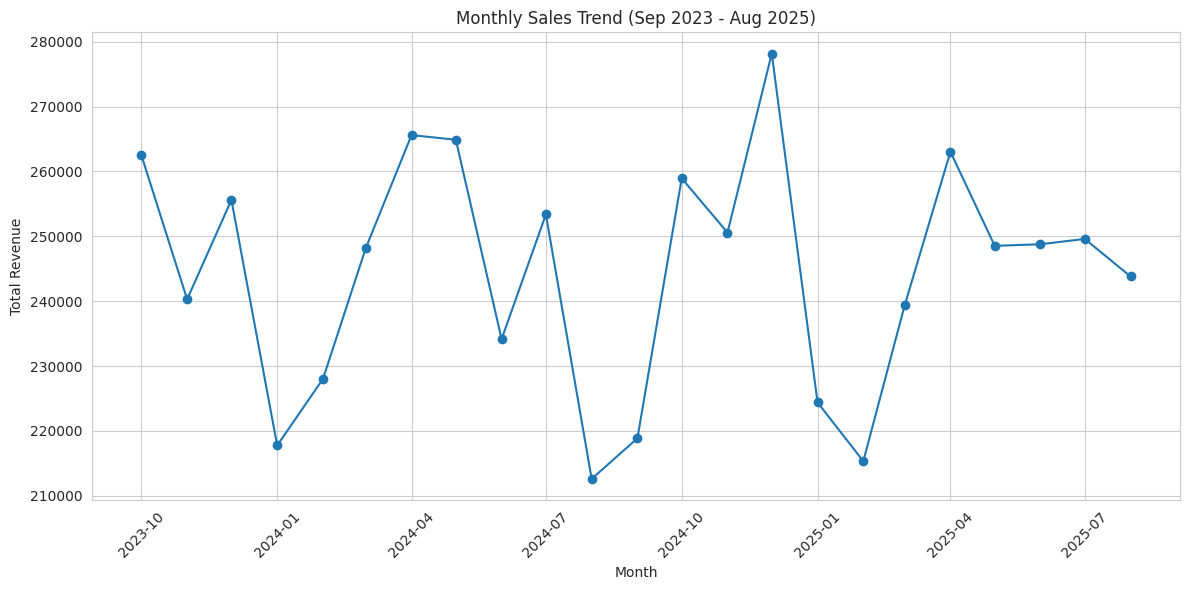

In [14]:
# Remove incomplete September 2025 data
# Keep only complete months
df_complete = df[
    (df['order_date'] >= '2023-10-01') &
    (df['order_date'] < '2025-09-01')
]

# Monthly Sales Trend
monthly_sales = df_complete.groupby(
    df_complete['order_date'].dt.to_period('M')
)['total_amount'].sum()

# Convert PeriodIndex to timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend (Sep 2023 - Aug 2025)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Revenue by Region
regional_sales = df.groupby('region')['total_amount'].sum().sort_values(ascending=False)

print("Revenue by Region:")
print(regional_sales)

Revenue by Region:
region
South      1298096.07
North      1264008.35
West       1186350.50
East       1176334.75
Central     940503.38
Name: total_amount, dtype: float64


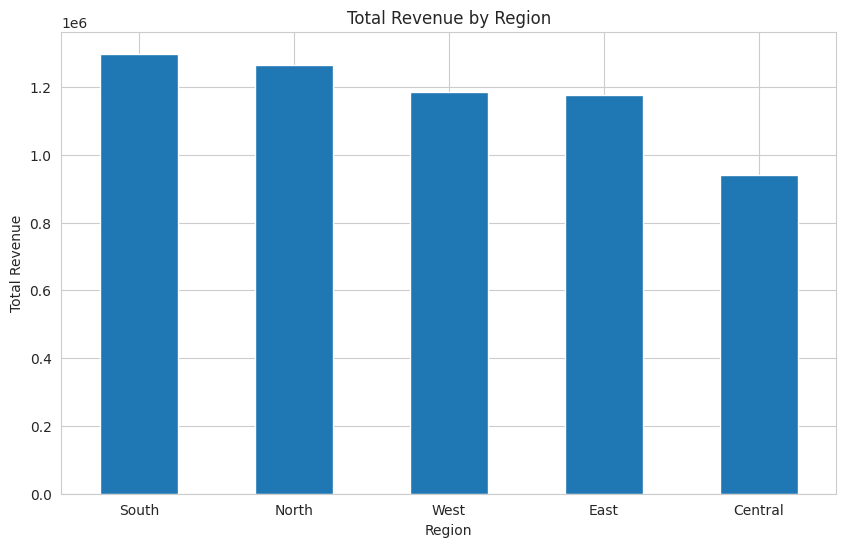

In [17]:
import matplotlib.pyplot as plt

regional_sales = df.groupby('region')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
regional_sales.plot(kind='bar')

plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

In [19]:
print(df.columns.tolist())

['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivery_time_days', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender', 'profit_percentage']


In [20]:
# Revenue by Product Category

category_sales = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)

print("Revenue by Product Category:")
print(category_sales)

Revenue by Product Category:
category
Electronics    3319206.50
Home           1077681.52
Sports          629825.54
Fashion         471545.80
Beauty          153019.38
Toys            132013.80
Grocery          82000.51
Name: total_amount, dtype: float64


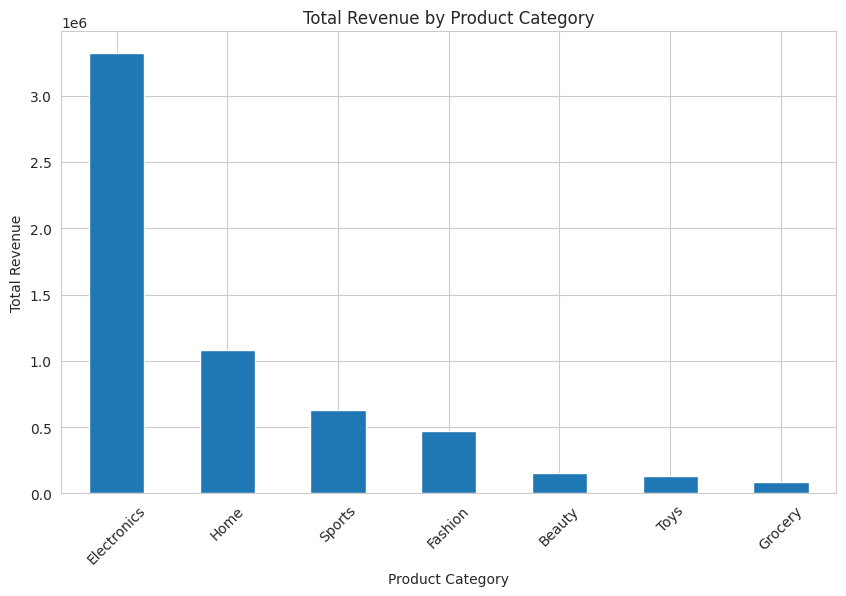

In [21]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind='bar')

plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [22]:
# Revenue by Payment Method
payment_sales = df.groupby('payment_method')['total_amount'].sum().sort_values(ascending=False)

print("Revenue by Payment Method:")
print(payment_sales)

Revenue by Payment Method:
payment_method
Credit Card    2056787.40
Debit Card     1460210.97
COD             715571.90
UPI             713642.96
PayPal          576523.32
Wallet          342556.50
Name: total_amount, dtype: float64


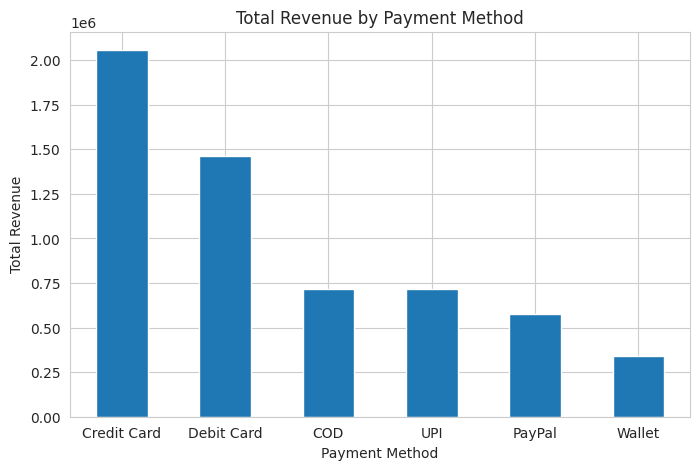

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

payment_sales.plot(kind='bar')

plt.title('Total Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')

plt.xticks(rotation=0)
plt.show()

In [24]:
# Top 10 Customers by Total Spending

top_customers = (
    df.groupby('customer_id')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Customers by Total Spending:")
print(top_customers)

Top 10 Customers by Total Spending:
customer_id
C16655    13885.10
C13565    11984.28
C15379    11375.58
C17116     7424.34
C15644     7244.07
C10975     7209.12
C16382     6973.06
C13767     6546.60
C15254     6509.95
C12427     6480.16
Name: total_amount, dtype: float64


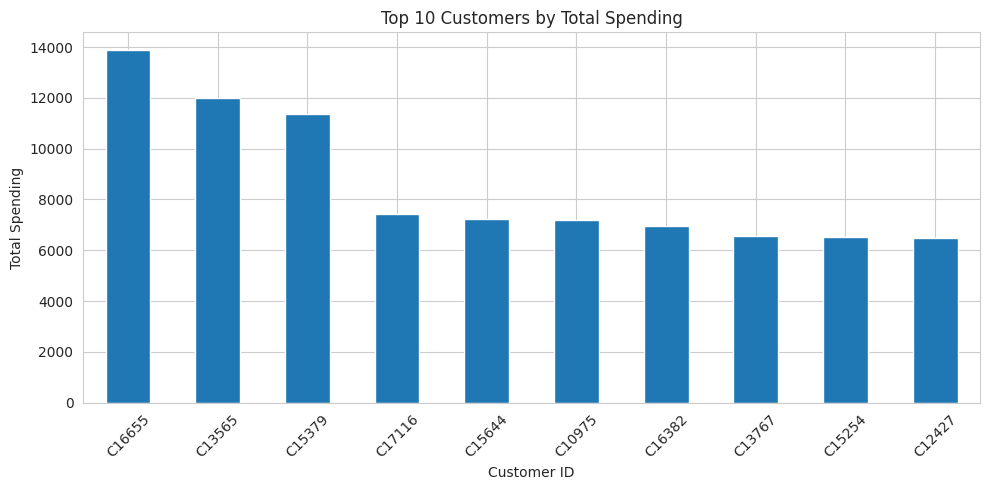

In [25]:
plt.figure(figsize=(10, 5))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
df['order_date'].head()

,order_date
0,2023-12-23
1,2025-04-03
2,2024-10-08
3,2024-09-14
4,2024-12-21


In [27]:
df['order_date'].dtype

dtype('<M8[ns]')

In [28]:
# Monthly Revenue Trend
monthly_sales = df.groupby(
    df['order_date'].dt.to_period('M')
)['total_amount'].sum()

print("Monthly Revenue Trend:")
print(monthly_sales)

Monthly Revenue Trend:
order_date
2023-09    151135.60
2023-10    262502.74
2023-11    240286.91
2023-12    255617.03
2024-01    217766.09
2024-02    228013.98
2024-03    248176.28
2024-04    265596.66
2024-05    264875.23
2024-06    234155.38
2024-07    253369.40
2024-08    212613.20
2024-09    218873.90
2024-10    258931.27
2024-11    250572.04
2024-12    278154.19
2025-01    224390.21
2025-02    215338.19
2025-03    239346.81
2025-04    263024.03
2025-05    248527.46
2025-06    248776.28
2025-07    249593.50
2025-08    243808.50
2025-09     91848.17
Freq: M, Name: total_amount, dtype: float64


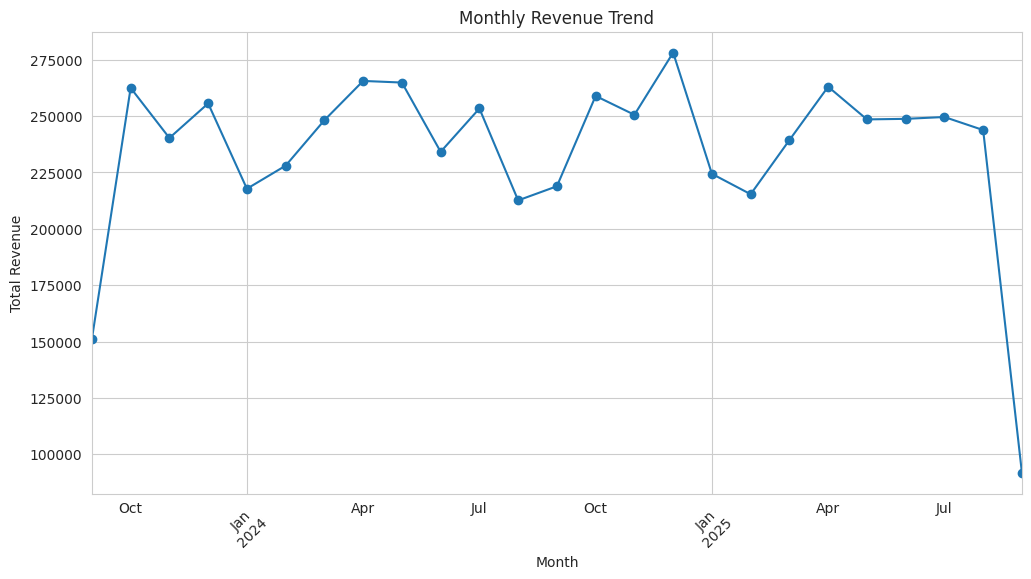

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [30]:
df['day_of_week'] = df['order_date'].dt.day_name()

df[['order_date', 'day_of_week']].head()

,order_date,day_of_week
0,2023-12-23,Saturday
1,2025-04-03,Thursday
2,2024-10-08,Tuesday
3,2024-09-14,Saturday
4,2024-12-21,Saturday


In [31]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_sales = (
    df.groupby('day_of_week')['total_amount']
    .sum()
    .reindex(day_order)
)

print("Revenue by Day of Week:")
print(daily_sales)

Revenue by Day of Week:
day_of_week
Monday       853282.82
Tuesday      866319.23
Wednesday    834664.71
Thursday     824795.02
Friday       826720.42
Saturday     810366.06
Sunday       849144.79
Name: total_amount, dtype: float64


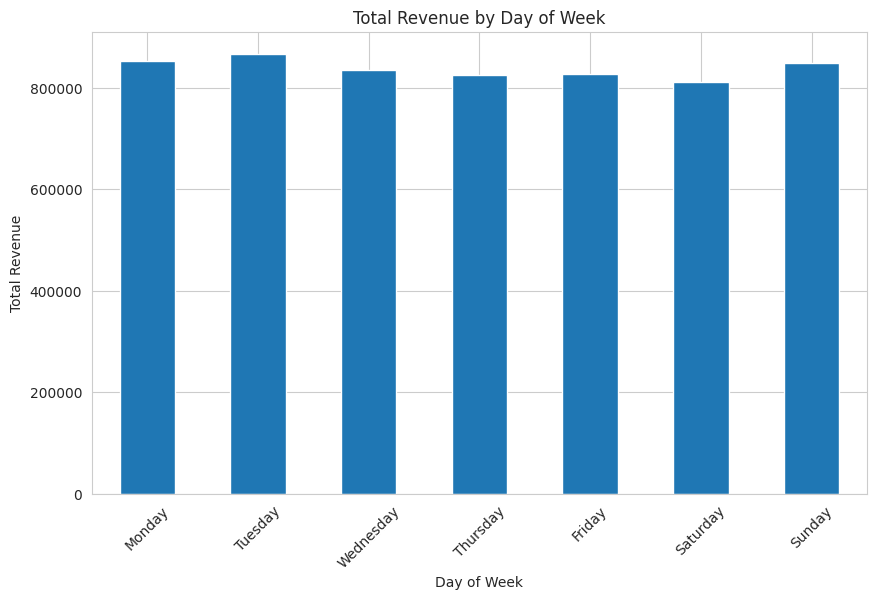

In [32]:
plt.figure(figsize=(10, 6))

daily_sales.plot(
    kind='bar'
)

plt.title('Total Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

In [33]:
# Quantity Sold by Product Category

category_quantity = (
    df.groupby('category')['quantity']
    .sum()
    .sort_values(ascending=False)
)

print("Total Quantity Sold by Category:")
print(category_quantity)

Total Quantity Sold by Category:
category
Electronics    9343
Fashion        9148
Home           8229
Toys           6313
Sports         6244
Beauty         6122
Grocery        6031
Name: quantity, dtype: int64


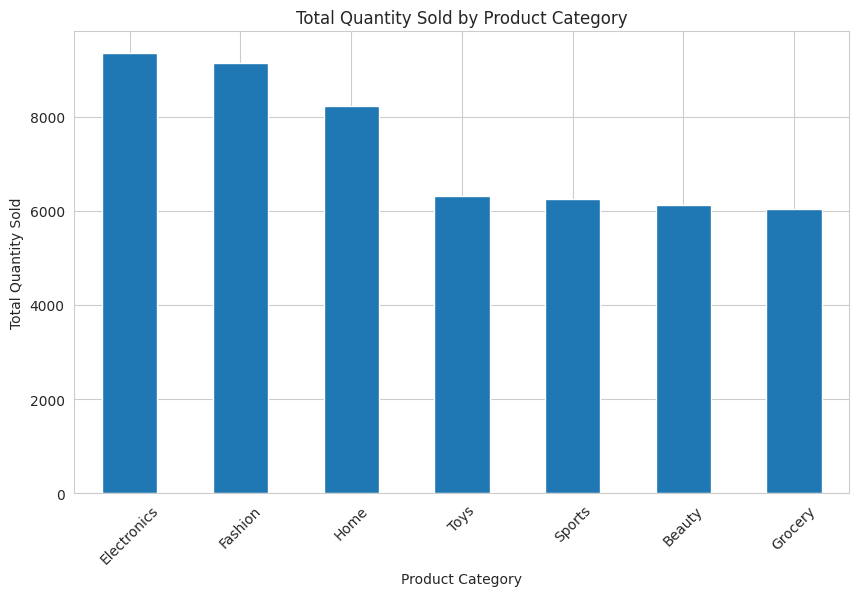

In [34]:
plt.figure(figsize=(10, 6))

category_quantity.plot(
    kind='bar'
)

plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)

plt.show()

In [36]:
# Key Business KPIs

total_revenue = df['total_amount'].sum()

total_orders = df['order_id'].nunique()

total_customers = df['customer_id'].nunique()

average_order_value = total_revenue / total_orders

total_quantity_sold = df['quantity'].sum()

print("KEY BUSINESS KPIs")
print("---------------------------")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Total Quantity Sold: {total_quantity_sold:,}")

KEY BUSINESS KPIs
---------------------------
Total Revenue: $5,865,293.05
Total Orders: 34,500
Total Customers: 7,903
Average Order Value: $170.01
Total Quantity Sold: 51,430


📊 Business Insights & Recommendations

Key Insights:

1. Electronics generated the highest revenue, making it the strongest-performing product category. However, Fashion showed strong demand in terms of quantity sold.
2. Credit Card was the leading payment method by revenue, followed by Debit Card, indicating that card-based transactions are the dominant payment preference.
3. The top 10 customers demonstrated significantly higher spending compared to individual average customer spending, highlighting an opportunity for loyalty programs and personalized promotions.
4. Monthly revenue showed fluctuations rather than a consistent growth pattern, suggesting potential seasonal patterns and opportunities for deeper time-series analysis.
5. Revenue remained relatively consistent across days of the week, indicating that sales are not heavily dependent on a particular weekday.
6. Electronics, Fashion, and Home had the highest product demand, based on total quantity sold.

Business Recommendations:

* Focus marketing and inventory planning on high-performing categories, particularly Electronics and Fashion.
* Introduce loyalty programs for high-value customers to improve retention.
* Analyze low-performing categories to identify opportunities for promotions or product optimization.
* Investigate monthly revenue fluctuations to identify possible seasonal trends.
* Optimize payment experiences around the most frequently used payment methods.bold text